In [15]:
# InceptionV3 + Advanced Tuning
# ================================

import os, cv2, random, numpy as np, tensorflow as tf, matplotlib.pyplot as plt, seaborn as sns
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, cohen_kappa_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [16]:
# -------- 1. CONFIG --------
IMG_SIZE = 299   # InceptionV3 standard size
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-5
NUM_CLASSES = 5
SAMPLES_PER_CLASS =1000

DATA_DIR = r"C:\Users\Krishna\Desktop\Diabetic Retinopathy Detection System\final_dataset\train"

CLASS_MAP = {
    "No_DR": 0,
    "Mild": 1,
    "Moderate": 2,
    "Severe": 3,
    "Proliferative_DR": 4
}


In [17]:
# -------- 2. DATA AUGMENTATION --------
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
])


In [18]:
def load_and_balance_data(data_dir, samples_per_class):
    image_paths, labels = [], []
    for class_name, label in CLASS_MAP.items():
        folder = os.path.join(data_dir, class_name)
        images = [os.path.join(folder, f) for f in os.listdir(folder)
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        count = len(images)

        if count >= samples_per_class:
            selected = random.sample(images, samples_per_class)
        else:
            selected = images * (samples_per_class // count) + random.sample(images, samples_per_class % count)

        image_paths.extend(selected)
        labels.extend([label] * samples_per_class)

    combined = list(zip(image_paths, labels))
    random.shuffle(combined)
    paths, labels = zip(*combined)
    return np.array(paths), np.array(labels)

In [19]:
def preprocess_image(path):
    img = cv2.imread(path)
    if img is None:
        return np.zeros((IMG_SIZE, IMG_SIZE, 3))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0,0), 10), -4, 128)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img.astype(np.float32) / 255.0

In [20]:
# -------- 5. DATA GENERATOR --------
class DRDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, labels, batch_size=32, shuffle=True):
        self.paths, self.labels = paths, labels
        self.batch_size, self.shuffle = batch_size, shuffle
        self.indexes = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        ids = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        X = np.array([preprocess_image(self.paths[i]) for i in ids])
        y = tf.keras.utils.to_categorical([self.labels[i] for i in ids], NUM_CLASSES)
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [21]:
# -------- 6. LOAD DATA --------
paths, labels = load_and_balance_data(DATA_DIR, SAMPLES_PER_CLASS)

X_train, X_test, y_train, y_test = train_test_split(paths, labels, test_size=0.2, stratify=labels, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.125, stratify=y_train, random_state=42)

train_gen = DRDataGenerator(X_train, y_train, BATCH_SIZE)
val_gen = DRDataGenerator(X_val, y_val, BATCH_SIZE)
test_gen = DRDataGenerator(X_test, y_test, BATCH_SIZE, shuffle=False)

In [22]:
# -------- 7. CLASS WEIGHTS --------
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0)}


In [23]:
# -------- 8. BUILD MODEL --------
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)

base_model = InceptionV3(weights='imagenet', include_top=False, input_tensor=x)

for layer in base_model.layers[:-80]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, output)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc_roc'),
        tf.keras.metrics.AUC(name='auc_pr', curve='PR')
    ]
)

In [24]:
# -------- 9. TRAINING --------
callbacks = [
    EarlyStopping(patience=3, restore_best_weights=True),
    ReduceLROnPlateau(patience=3),
    ModelCheckpoint("best_dr_model_inception.keras", save_best_only=True)
]

history = model.fit(train_gen, validation_data=val_gen,
                    epochs=EPOCHS, callbacks=callbacks,
                    class_weight=class_weights)

C:\Users\Krishna\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 543s 5s/step - accuracy: 0.2451 - auc_pr: 0.2335 - auc_roc: 0.5545 - loss: 1.6505 - precision: 0.2919 - recall: 0.0134 - val_accuracy: 0.3360 - val_auc_pr: 0.3335 - val_auc_roc: 0.6668 - val_loss: 1.5028 - val_precision: 1.0000 - val_recall: 0.0020 - learning_rate: 1.0000e-05
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 583s 5s/step - accuracy: 0.3177 - auc_pr: 0.3106 - auc_roc: 0.6378 - loss: 1.5316 - precision: 0.5044 - recall: 0.0326 - val_accuracy: 0.3660 - val_auc_pr: 0.3660 - val_auc_roc: 0.7051 - val_loss: 1.4341 - val_precision: 0.5882 - val_recall: 0.0200 - learning_rate: 1.0000e-05
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 594s 5s/step - accuracy: 0.3614 - auc_pr: 0.3699 - auc_roc: 0.6985 - loss: 1.4392 - precision: 0.5849 - recall: 0.0709 - val_accuracy: 0.4080 - val_auc_pr: 0.3985 - val_auc_roc: 0.7324 - val_loss: 1.3854 - val_precision: 0.6667 - val_recall: 0.0360 - learning_rate: 1.0000e-05
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 579s 5s/s

In [25]:
y_pred_prob = model.predict(test_gen)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test[:len(y_pred)]

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=CLASS_MAP.keys()))
print("Quadratic Kappa:", cohen_kappa_score(y_true, y_pred, weights='quadratic'))

32/32 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step 

Classification Report:
                   precision    recall  f1-score   support

           No_DR       0.42      0.47      0.44       200
            Mild       0.39      0.49      0.43       200
        Moderate       0.40      0.16      0.23       200
          Severe       0.47      0.65      0.54       200
Proliferative_DR       0.69      0.56      0.61       200

        accuracy                           0.47      1000
       macro avg       0.47      0.47      0.45      1000
    weighted avg       0.47      0.47      0.45      1000

Quadratic Kappa: 0.6774351443954968


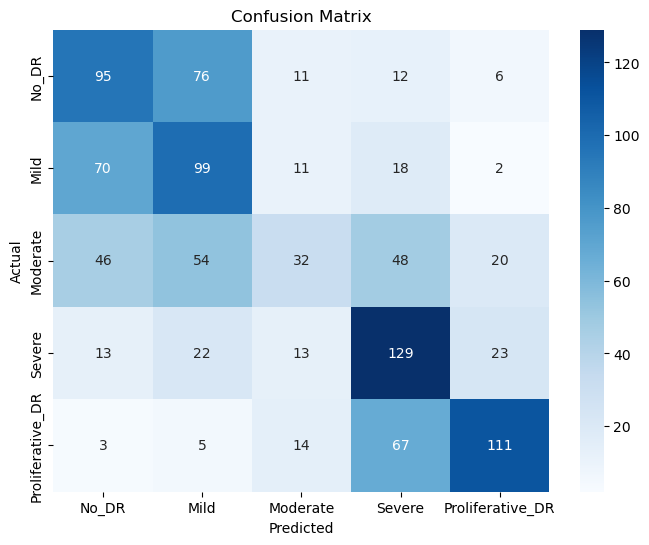

In [26]:
# -------- 11. CONFUSION MATRIX --------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_MAP.keys(), yticklabels=CLASS_MAP.keys())
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

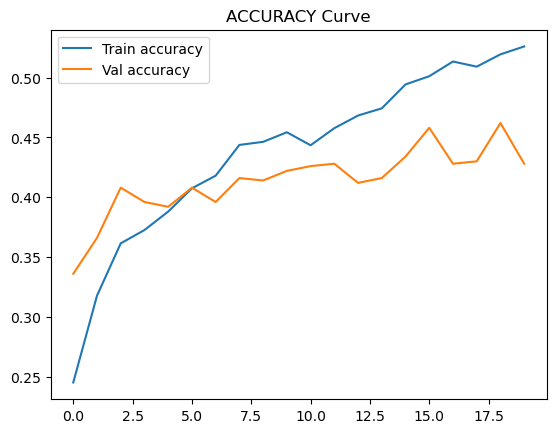

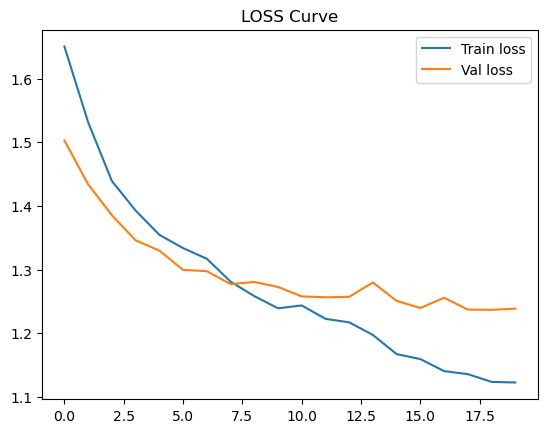

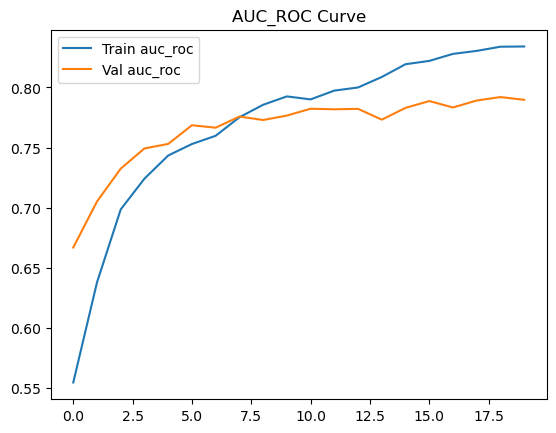

In [28]:
# -------- 12. LEARNING CURVES --------
metrics = ['accuracy', 'loss', 'auc_roc']
for m in metrics:
    plt.plot(history.history[m], label=f"Train {m}")
    plt.plot(history.history[f"val_{m}"], label=f"Val {m}")
    plt.title(f"{m.upper()} Curve")
    plt.legend()
    plt.show()


In [29]:
# -------- 13. SAVE FINAL MODEL --------
model.save("final_dr_model_inception.keras")
print("\nModel saved successfully!")


Model saved successfully!


In [2]:
import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model("final_dr_model_inception.keras")

# Convert to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimization (VERY IMPORTANT)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save compressed model
with open("dr_model_compressed.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully!")


INFO:tensorflow:Assets written to: C:\Users\Krishna\AppData\Local\Temp\tmp0mn8uj3k\assets


INFO:tensorflow:Assets written to: C:\Users\Krishna\AppData\Local\Temp\tmp0mn8uj3k\assets


Saved artifact at 'C:\Users\Krishna\AppData\Local\Temp\tmp0mn8uj3k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  1436873238352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873238736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873238544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873237968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873238928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873239888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873239696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873240080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873240272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1436873239312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14